# World Population — Complete ML & EDA Project

# Import Libraries & Load Dataset

In [53]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Data Collection
# Load the dataset (example: world_population.csv)
df = pd.read_csv('world_population.csv')

# Display basic info about the dataset
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country/Territory            234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area (km²)          

# Data Pre-Processing

In [54]:
# Data Preprocessing
# Handle missing values
data = df.dropna()
data.head

<bound method NDFrame.head of      Rank CCA3  Country/Territory           Capital Continent  \
0      36  AFG        Afghanistan             Kabul      Asia   
1     138  ALB            Albania            Tirana    Europe   
2      34  DZA            Algeria           Algiers    Africa   
3     213  ASM     American Samoa         Pago Pago   Oceania   
4     203  AND            Andorra  Andorra la Vella    Europe   
..    ...  ...                ...               ...       ...   
229   226  WLF  Wallis and Futuna          Mata-Utu   Oceania   
230   172  ESH     Western Sahara          El Aaiún    Africa   
231    46  YEM              Yemen             Sanaa      Asia   
232    63  ZMB             Zambia            Lusaka    Africa   
233    74  ZWE           Zimbabwe            Harare    Africa   

     2022 Population  2020 Population  2015 Population  2010 Population  \
0           41128771         38972230         33753499         28189672   
1            2842321          2866849  

# Feature Engineering — Growth Rate

In [55]:
# Feature Engineering
# Create additional feature: calculated growth rate from 2020–2022
data['Calculated_GrowthRate'] = ((data['2022 Population'] - data['2020 Population']) 
                                  / data['2020 Population']) * 100

# Drop NA after feature creation (as PDF says)
data = data.dropna()

# Verify new column
data[['Country/Territory','Growth Rate','Calculated_GrowthRate']].head()


,Country/Territory,Growth Rate,Calculated_GrowthRate
0,Afghanistan,1.0257,5.533532
1,Albania,0.9957,-0.855573
2,Algeria,1.0164,3.340629
3,American Samoa,0.9831,-4.148174
4,Andorra,1.0100,2.733591


# Define Features & Target

In [56]:
# Define features and target variable
features = ['Area (km²)', 'Density (per km²)', 'Growth Rate', 'World Population Percentage']

X = data[features]
y = data['2022 Population']

# Train-Test Split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)


## Feature Scaling

In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train the Model

In [59]:
# Model Building
model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

## Predict on Test Data

In [60]:
# Predict on the test set
y_pred = model.predict(X_test_scaled)


# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse) #Big number because population is in billions 
print("R^2 Score:", r2)


Mean Squared Error: 57973277596.18385
R^2 Score: 0.9999849093566933


## Visualize Actual vs Predicted

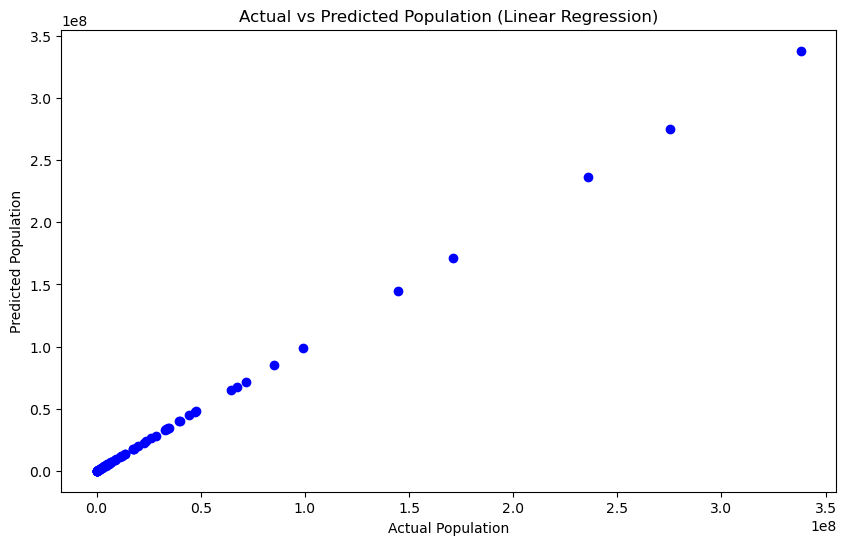

In [61]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Actual Population")
plt.ylabel("Predicted Population")
plt.title("Actual vs Predicted Population (Linear Regression)")
plt.show()


In [62]:
df = data.copy()

# Custom color plate
custom_palette = ['#0b3d91', '#e0f7fa', '#228b22', '#1e90ff', 
                  '#8B4513', '#D2691E', '#DAA520', '#556B2F']

# Number of Countries by Continent

In [63]:
countries_by_continent = df['Continent'].value_counts().reset_index()
countries_by_continent.columns = ['Continent', 'count']

fig = px.bar(
    countries_by_continent,
    x='Continent',
    y='count',
    color='Continent',
    text='count',
    title='Number of Countries by Continent',
    color_discrete_sequence=custom_palette
)

fig.update_layout(
    xaxis_title='Continents',
    yaxis_title='Number of Countries',
    plot_bgcolor='rgba(0,0,0,0)',
    font_family='Arial',
    title_font_size=20
)

fig.show()


# World Population Percentage by Continent

In [64]:
continent_population_percentage = df.groupby('Continent')['World Population Percentage'].sum().reset_index()

fig = go.Figure(data=[go.Pie(
    labels=continent_population_percentage['Continent'],
    values=continent_population_percentage['World Population Percentage']
)])

fig.update_layout(
    title='World Population Percentage by Continent',
    template='plotly',
    paper_bgcolor='rgba(255,255,255,0)',
    plot_bgcolor='rgba(255,255,255,0)'
)

fig.update_traces(marker=dict(colors=custom_palette, 
                              line=dict(color='#FFFFFF', width=1)))

fig.show()


# Population Trends by Continent Over Time

In [65]:
df_melted = df.melt(
    id_vars=['Continent'],
    value_vars=[
        '2022 Population','2020 Population','2015 Population',
        '2010 Population','2000 Population','1990 Population',
        '1980 Population','1970 Population'
    ],
    var_name='Year',
    value_name='Population'
)

df_melted['Year'] = df_melted['Year'].str.split().str[0].astype(int)

population_by_continent = df_melted.groupby(['Continent','Year']).sum().reset_index()

fig = px.line(
    population_by_continent, 
    x='Year', 
    y='Population', 
    color='Continent',
    title='Population Trends by Continent Over Time',
    labels={'Population':'Population','Year':'Year'},
    color_discrete_sequence=custom_palette
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Year',
    yaxis_title='Population',
    font_family='Arial',
    title_font_size=20
)

fig.update_traces(line=dict(width=3))
fig.show()


# World Population Map (1970 & 2020)

In [66]:
features=['1970 Population','2020 Population']

for feature in features:
    fig = px.choropleth(
        df,
        locations='Country/Territory',
        locationmode='country names',
        color=feature,
        hover_name='Country/Territory',
        template='plotly_white',
        title = feature
    )
    fig.show()

# India grew from ~557M (1970) to ~1.4B (2020)


# Growth of Population (1970 to 2022 and  Top 8 Countries)

In [67]:
growth = (
    df.groupby('Country/Territory')['2022 Population'].sum()
    - df.groupby('Country/Territory')['1970 Population'].sum()
).sort_values(ascending=False).head(8)

fig = px.bar(
    x=growth.index,
    y=growth.values,
    text=growth.values,
    color=growth.values,
    title='Growth Of Population From 1970 to 2022 (Top 8)',
    template='plotly_white'
)

fig.update_layout(
    xaxis_title='Country',
    yaxis_title='Population Growth'
)

fig.show()


# Top 8 Most Populated Countries (1970 & 2022)

In [68]:
top_8_populated_countries_1970 = df.groupby('Country/Territory')['1970 Population'].sum().sort_values(ascending=False).head(8)
top_8_populated_countries_2022 = df.groupby('Country/Territory')['2022 Population'].sum().sort_values(ascending=False).head(8)


features = {
    'Top 8 Most Populated Countries (1970)': top_8_populated_countries_1970,
    'Top 8 Most Populated Countries (2022)': top_8_populated_countries_2022
}

for title, data_values in features.items():
    fig = px.bar(
        x=data_values.index,
        y=data_values.values,
        text=data_values.values,
        color=data_values.values,
        title=title,
        template='plotly_white'
    )

    fig.update_layout(
        xaxis_title='Country',
        yaxis_title='Population'
    )

    fig.show()


# Fastest & Slowest Growing Countries (Growth Rate Basis)

In [69]:
sorted_df_growth = df.sort_values(by='Growth Rate', ascending=False)

top_fastest = sorted_df_growth.head(6)




def plot_population_trends(countries):
    n_cols = 2
    n_rows = (len(countries) + n_cols - 1) // n_cols
    
    fig = make_subplots(
        rows=n_rows,
        cols=n_cols,
        subplot_titles=countries,
        horizontal_spacing=0.1,
        vertical_spacing=0.1
    )
    
    for i, country in enumerate(countries, start=1):
        country_df = df[df['Country/Territory'] == country]
        
        melted = country_df.melt(
            id_vars=['Country/Territory'],
            value_vars=['1970 Population','1980 Population','1990 Population',
                        '2000 Population','2010 Population','2015 Population',
                        '2020 Population','2022 Population'],
            var_name='Year',
            value_name='Population'
        )
        
        melted['Year'] = melted['Year'].str.split().str[0].astype(int)

        temp_fig = px.line(melted, x='Year', y='Population',
                           color='Country/Territory')

        row = (i - 1) // n_cols + 1
        col = (i - 1) % n_cols + 1
        
        for trace in temp_fig.data:
            fig.add_trace(trace, row=row, col=col)

    fig.update_layout(
        title="Population Trends of Fastest Growing Countries",
        template="plotly_white",
        showlegend=False,
        height=600*n_rows
    )

    fig.show()

fastest_countries = top_fastest['Country/Territory'].tolist()
plot_population_trends(fastest_countries)


# Slowest Growing Countries

In [70]:
top_slowest = sorted_df_growth.tail(6)

slowest_countries = top_slowest['Country/Territory'].tolist()
plot_population_trends(slowest_countries)


# Countries with MOST & LEAST Land Area

In [71]:

# Calculate total land area per country
land_by_country = df.groupby('Country/Territory')['Area (km²)'].sum().sort_values(ascending=False)

most_land = land_by_country.head(5)
least_land = land_by_country.tail(5)

# Plot twin-bar charts


fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Countries with Most Land", "Countries with Least Land")
)

# Most land chart
fig.add_trace(
    go.Bar(x=most_land.index, y=most_land.values, name="Most Land"),
    row=1, col=1
)

# Least land chart
fig.add_trace(
    go.Bar(x=least_land.index, y=least_land.values, name="Least Land"),
    row=1, col=2
)

fig.update_layout(
    title_text="Geographical Distribution of Land Area by Country",
    template="plotly_white",
    showlegend=False
)

fig.update_yaxes(title_text="Area (km²)", row=1, col=1)
fig.update_yaxes(title_text="Area (km²)", row=1, col=2)

fig.show()


# Land Area Available PER PERSON

In [72]:
# Formula --> Area per Person = Total Area ÷ Population
# Create new feature area/person
df['Area per Person'] = df['Area (km²)'] / df['2022 Population']

# Rank countries
country_area_per_person = df.groupby('Country/Territory')['Area per Person'].sum()

most_land_available = country_area_per_person.sort_values(ascending=False).head(5)
least_land_available = country_area_per_person.sort_values(ascending=False).tail(5)

# Plot charts side by side
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Countries with Most Land Available Per Capita",
                    "Countries with Least Land Available Per Capita")
)

fig.add_trace(
    go.Bar(x=most_land_available.index, y=most_land_available.values),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=least_land_available.index, y=least_land_available.values),
    row=1, col=2
)

fig.update_layout(
    title_text="Distribution of Available Land Area by Country Per Capita",
    template="plotly_white",
    showlegend=False
)

fig.update_yaxes(title_text="Land Available Per Person", row=1, col=1)
fig.update_yaxes(title_text="Land Available Per Person", row=1, col=2)

fig.show()



In [73]:


# Data prepare karna (Top 5 vs Bottom 5)
most_land = df.sort_values(by='Area per Person', ascending=False).head(5)
least_land = df.sort_values(by='Area per Person', ascending=True).head(5)

# PDF Page 27 ke mutabik Subplots banana
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=("Most Land Available Per Capita", "Least Land Available Per Capita"))

# Most Land Bar Chart
fig.add_trace(go.Bar(x=most_land['Country/Territory'], y=most_land['Area per Person'], 
                     marker_color='green', name='Most'), row=1, col=1)

# Least Land Bar Chart
fig.add_trace(go.Bar(x=least_land['Country/Territory'], y=least_land['Area per Person'], 
                     marker_color='red', name='Least'), row=1, col=2)

fig.update_layout(title_text="Geographical Land Distribution Analysis (PDF Requirement)", height=500)
fig.show()

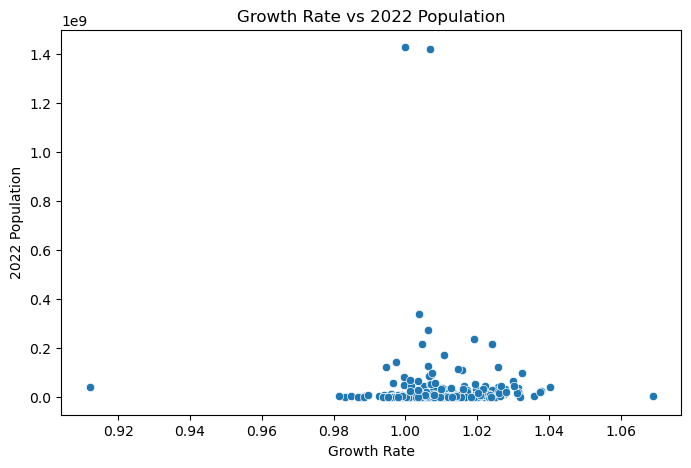

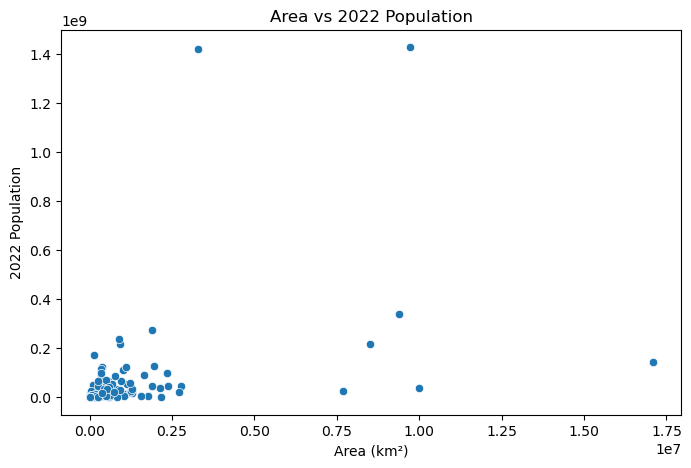

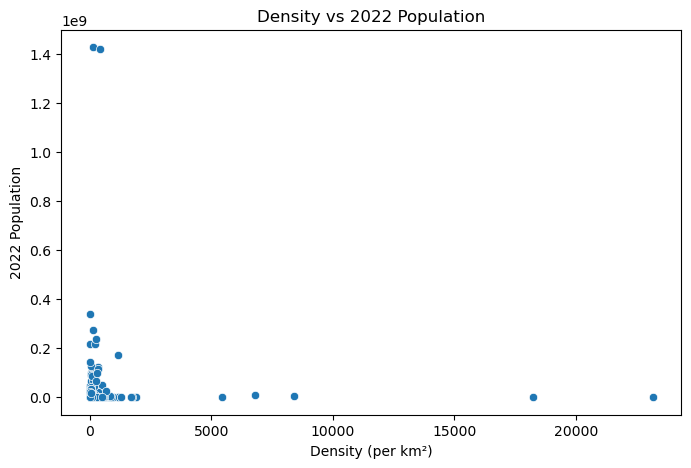

In [74]:
# Growth Rate vs Population (Better Insight)
plt.figure(figsize=(8,5))
sns.scatterplot(x='Growth Rate', y='2022 Population', data=df)
plt.title("Growth Rate vs 2022 Population")
plt.show()

# Area vs Population
plt.figure(figsize=(8,5))
sns.scatterplot(x='Area (km²)', y='2022 Population', data=df)
plt.title("Area vs 2022 Population")
plt.show()

# Density vs Population (Strong Visualization)
plt.figure(figsize=(8,5))
sns.scatterplot(x='Density (per km²)', y='2022 Population', data=df)
plt.title("Density vs 2022 Population")
plt.show()

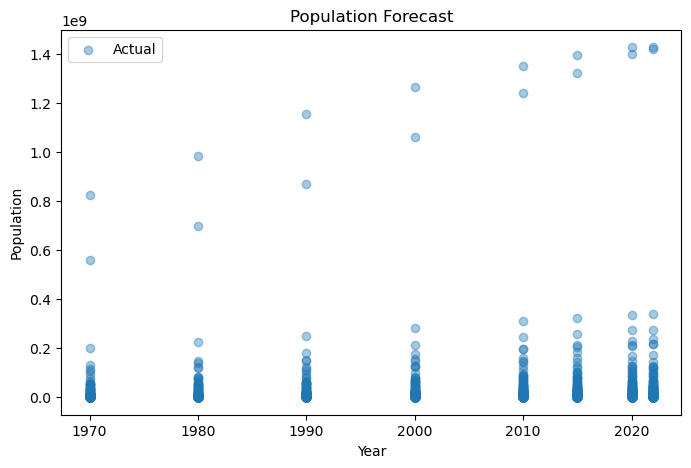

In [75]:
# Full dataset prediction 
# Convert wide format to long format
df_long = df.melt(
    id_vars=['Country/Territory'],
    value_vars=[
        '1970 Population',
        '1980 Population',
        '1990 Population',
        '2000 Population',
        '2010 Population',
        '2015 Population',
        '2020 Population',
        '2022 Population'
    ],
    var_name='Year',
    value_name='Population'
)

# Extract numeric year
df_long['Year'] = df_long['Year'].str.split().str[0].astype(int)

df_long.head()
X_all = df_long[['Year']]
y_all = df_long['Population']

plt.figure(figsize=(8,5))

plt.scatter(df_long['Year'], y_all, alpha=0.4, label='Actual')

plt.legend()
plt.title("Population Forecast")
plt.xlabel("Year")
plt.ylabel("Population")
plt.show()